# **Project Name**    -  **Voyage Analytics - Gender Prediction**

##### **Project Type**    - Classification

# **Problem Statement**

Predict a user's gender using their travel behavior (flights and hotels booking patterns) merged with the users dataset. This is a classification problem to help personalize recommendations.

# **General Guidelines**
- Follow the same notebook structure used in the Telecom Churn reference notebooks.
- Answer every 'why' question in markdown before moving to the next section.
- Keep chart storytelling format: Why this chart -> Insight -> Business impact.

# ***Let's Begin!***

## ***1. Know Your Data***

### Import Libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

pd.set_option('display.max_columns', None)
%matplotlib inline

### Dataset Loading

In [6]:
users = pd.read_csv('../data/users.csv')
flights = pd.read_csv('../data/flights.csv')
hotels = pd.read_csv('../data/hotels.csv')

print(users.shape, flights.shape, hotels.shape)

(1340, 5) (271888, 10) (40552, 8)


### Dataset First View

In [7]:
users.head()

,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44


In [8]:
flights.head()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019


In [9]:
hotels.head()

,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019


### Merge datasets
users -> `code`, flights/hotels -> `userCode`. Merge on that key as needed for this task.

In [10]:
# Example merge - adapt columns/keys as required for this specific task
# df = flights.merge(users, left_on='userCode', right_on='code', how='left')
# df.head()

### Dataset Rows & Columns count

In [11]:
for name, d in [('users', users), ('flights', flights), ('hotels', hotels)]:
    print(name, d.shape)

users (1340, 5)
flights (271888, 10)
hotels (40552, 8)


### Dataset Information

In [12]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   code     1340 non-null   int64 
 1   company  1340 non-null   object
 2   name     1340 non-null   object
 3   gender   1340 non-null   object
 4   age      1340 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 52.5+ KB


In [13]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   travelCode  271888 non-null  int64  
 1   userCode    271888 non-null  int64  
 2   from        271888 non-null  object 
 3   to          271888 non-null  object 
 4   flightType  271888 non-null  object 
 5   price       271888 non-null  float64
 6   time        271888 non-null  float64
 7   distance    271888 non-null  float64
 8   agency      271888 non-null  object 
 9   date        271888 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 20.7+ MB


In [14]:
hotels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40552 entries, 0 to 40551
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   travelCode  40552 non-null  int64  
 1   userCode    40552 non-null  int64  
 2   name        40552 non-null  object 
 3   place       40552 non-null  object 
 4   days        40552 non-null  int64  
 5   price       40552 non-null  float64
 6   total       40552 non-null  float64
 7   date        40552 non-null  object 
dtypes: float64(2), int64(3), object(3)
memory usage: 2.5+ MB


#### Duplicate Values

In [15]:
print('users duplicates:', users.duplicated().sum())
print('flights duplicates:', flights.duplicated().sum())
print('hotels duplicates:', hotels.duplicated().sum())

users duplicates: 0
flights duplicates: 0
hotels duplicates: 0


#### Missing Values/Null Values

In [16]:
print(users.isnull().sum())
print(flights.isnull().sum())
print(hotels.isnull().sum())

code       0
company    0
name       0
gender     0
age        0
dtype: int64
travelCode    0
userCode      0
from          0
to            0
flightType    0
price         0
time          0
distance      0
agency        0
date          0
dtype: int64
travelCode    0
userCode      0
name          0
place         0
days          0
price         0
total         0
date          0
dtype: int64


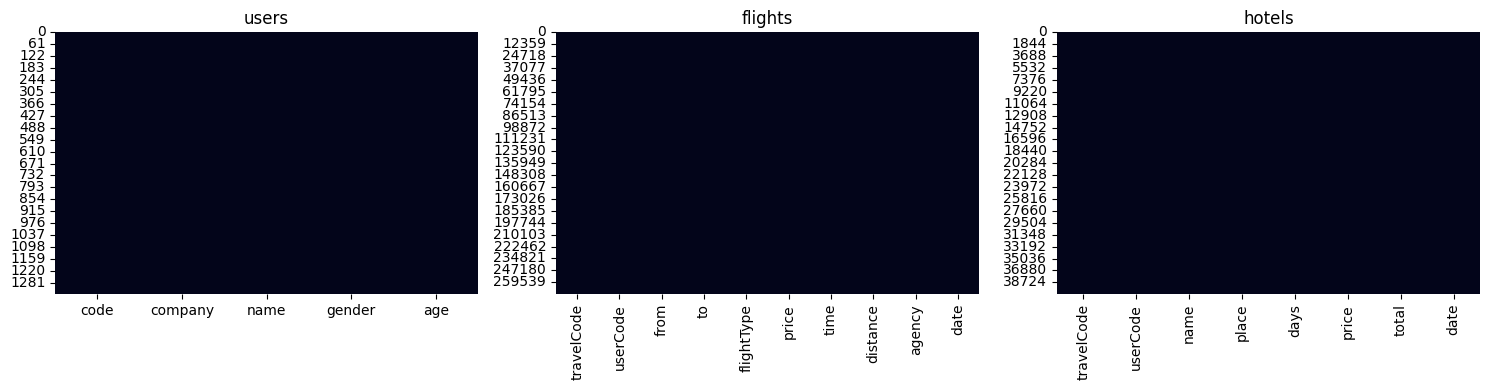

In [17]:
# Visualize missing values
fig, ax = plt.subplots(1,3, figsize=(15,4))
sns.heatmap(users.isnull(), cbar=False, ax=ax[0]); ax[0].set_title('users')
sns.heatmap(flights.isnull(), cbar=False, ax=ax[1]); ax[1].set_title('flights')
sns.heatmap(hotels.isnull(), cbar=False, ax=ax[2]); ax[2].set_title('hotels')
plt.tight_layout(); plt.show()

### What did you know about your dataset?
_(Write your observations here)_

## ***2. Understanding Your Variables***

### Variables Description
_(Describe each column: what it represents, dtype, and relevance to this task)_

### Check Unique Values for each variable.

In [18]:
for col in users.columns:
    print(col, '->', users[col].nunique())

code -> 1340
company -> 5
name -> 1338
gender -> 3
age -> 45


In [40]:
# 1. Merge flights + hotels with users on the common key
# Check column names first to confirm the join key
print(users.columns.tolist())
print(flights.columns.tolist())
print(hotels.columns.tolist())

['code', 'company', 'name', 'gender', 'age']
['travelCode', 'userCode', 'from', 'to', 'flightType', 'price', 'time', 'distance', 'agency', 'date']
['travelCode', 'userCode', 'name', 'place', 'days', 'price', 'total', 'date']


## 3. ***Data Wrangling***

### Data Wrangling Code

In [41]:
# Handle missing values, fix dtypes, create merged working dataframe here

# 1. Aggregate flight behavior per user
flights_agg = flights.groupby('userCode').agg(
    total_flights=('travelCode', 'count'),
    avg_flight_price=('price', 'mean'),
    avg_distance=('distance', 'mean'),
    avg_flight_time=('time', 'mean')
).reset_index()

# 2. Aggregate hotel behavior per user
hotels_agg = hotels.groupby('userCode').agg(
    total_hotel_bookings=('travelCode', 'count'),
    avg_hotel_price=('total', 'mean'),
    avg_days=('days', 'mean')
).reset_index()

# 3. Merge users with flight aggregates
df = users.merge(flights_agg, left_on='code', right_on='userCode', how='left')

# 4. Merge with hotel aggregates
df = df.merge(hotels_agg, left_on='code', right_on='userCode', how='left', suffixes=('', '_hotel'))

# 5. Drop duplicate/unneeded columns from the merge
df.drop(columns=['userCode', 'userCode_hotel'], inplace=True, errors='ignore')

# 6. Handle missing values created by merge (users with no flight/hotel history)
df.fillna(0, inplace=True)

# 7. Quick check
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   code                  1340 non-null   int64  
 1   company               1340 non-null   object 
 2   name                  1340 non-null   object 
 3   gender                1340 non-null   object 
 4   age                   1340 non-null   int64  
 5   total_flights         1340 non-null   float64
 6   avg_flight_price      1340 non-null   float64
 7   avg_distance          1340 non-null   float64
 8   avg_flight_time       1340 non-null   float64
 9   total_hotel_bookings  1340 non-null   float64
 10  avg_hotel_price       1340 non-null   float64
 11  avg_days              1340 non-null   float64
dtypes: float64(7), int64(2), object(3)
memory usage: 125.8+ KB


,code,company,name,gender,age,total_flights,avg_flight_price,avg_distance,avg_flight_time,total_hotel_bookings,avg_hotel_price,avg_days
0,0,4You,Roy Braun,male,21,178.0,989.066124,527.233596,1.370337,27.0,593.145185,2.629630
1,1,4You,Joseph Holsten,male,37,12.0,818.898333,508.648333,1.321667,2.0,193.360000,1.000000
2,2,4You,Wilma Mcinnis,female,48,262.0,906.921832,513.671374,1.335191,36.0,558.003333,2.694444
3,3,4You,Paula Daniel,female,23,398.0,936.913894,506.074372,1.315176,60.0,499.568500,2.300000
4,4,4You,Patricia Carson,female,44,398.0,957.393417,517.955477,1.345930,56.0,565.316071,2.571429


### What all manipulations have you done and insights you found?


Merged users with aggregated flight and hotel booking behavior (grouped by userCode). Final dataset has 1340 users with 12 features, no missing values after merge. Target variable is 'gender' (male/female).

## ***4. Data Visualization, Storytelling & Experimenting with charts***

#### Chart - 1

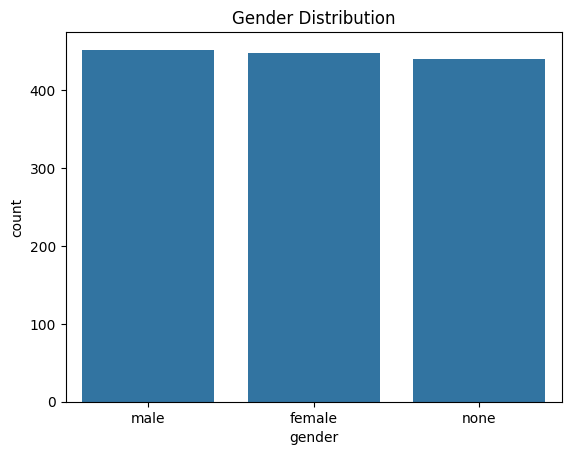

In [42]:
# Chart 1 — Gender distribution:

sns.countplot(data=df, x='gender')
plt.title('Gender Distribution')
plt.show()

##### 1. Why did you pick the specific chart?
_(answer)_

##### 2. What is/are the insight(s) found from the chart?
_(answer)_

##### 3. Will the gained insights help creating a positive business impact?
_(answer)_

#### Chart - 2

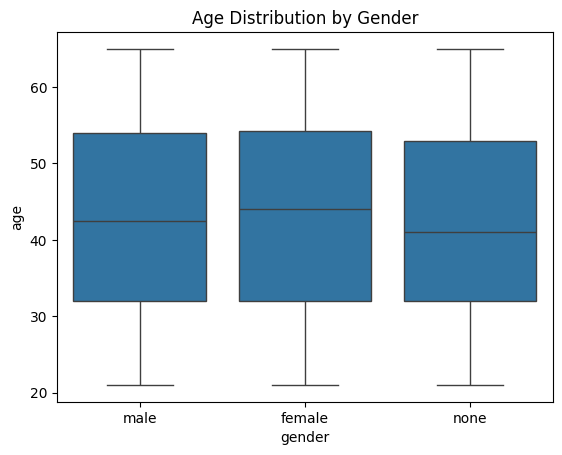

In [43]:
# Chart 2 — Age vs Gender:
sns.boxplot(data=df, x='gender', y='age')
plt.title('Age Distribution by Gender')
plt.show()

##### 1. Why did you pick the specific chart?
_(answer)_

##### 2. What is/are the insight(s) found from the chart?
_(answer)_

##### 3. Will the gained insights help creating a positive business impact?
_(answer)_

#### Chart - 3

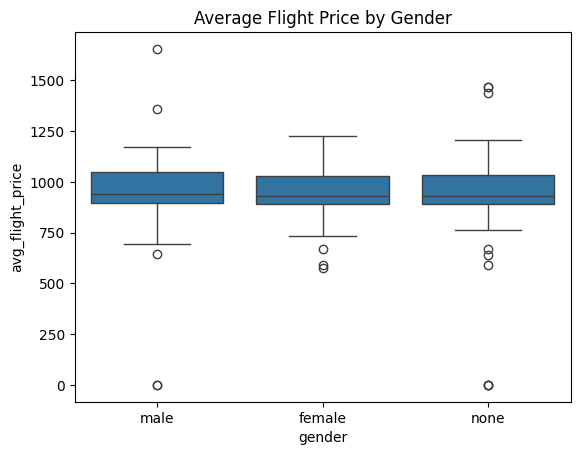

In [44]:
# Chart 3 — Avg flight price vs Gender:

sns.boxplot(data=df, x='gender', y='avg_flight_price')
plt.title('Average Flight Price by Gender')
plt.show()

##### 1. Why did you pick the specific chart?
_(answer)_

##### 2. What is/are the insight(s) found from the chart?
_(answer)_

##### 3. Will the gained insights help creating a positive business impact?
_(answer)_

#### Chart - 4

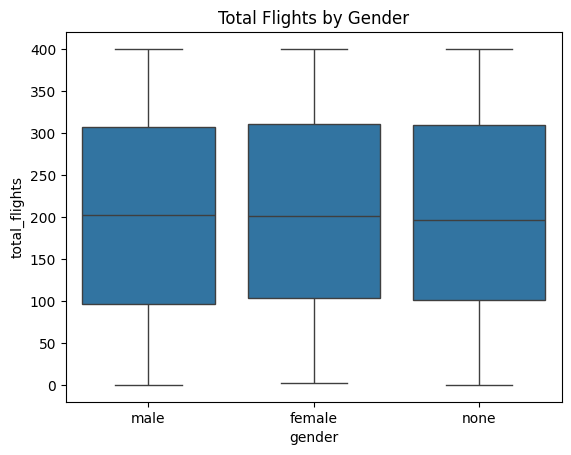

In [45]:
# Chart 4 — Total flights vs Gender:

sns.boxplot(data=df, x='gender', y='total_flights')
plt.title('Total Flights by Gender')
plt.show()

##### 1. Why did you pick the specific chart?
_(answer)_

##### 2. What is/are the insight(s) found from the chart?
_(answer)_

##### 3. Will the gained insights help creating a positive business impact?
_(answer)_

#### Chart - 5

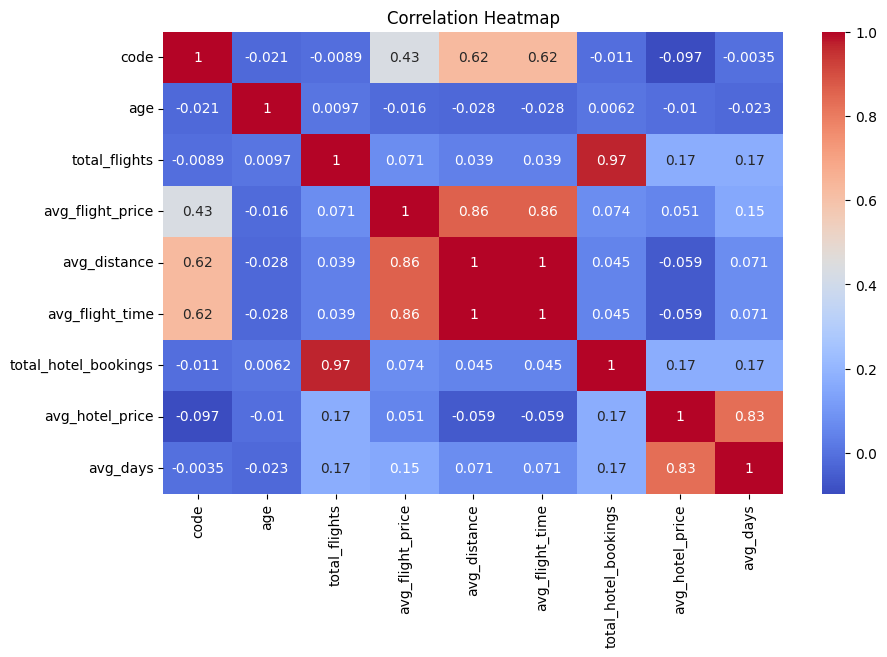

In [46]:
# Chart 5 — Correlation heatmap:

plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

##### 1. Why did you pick the specific chart?
_(answer)_

##### 2. What is/are the insight(s) found from the chart?
_(answer)_

##### 3. Will the gained insights help creating a positive business impact?
_(answer)_

## ***5. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [25]:
# imputation code

### 2. Handling Outliers

In [26]:
# outlier treatment code

### 3. Categorical Encoding

In [27]:
# encode categorical columns (agency, place, flightType, etc.)

### 4. Feature Selection

In [28]:
# correlation / feature importance based selection

### 5. Data Scaling

In [29]:
from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()

### 6. Data Splitting

In [30]:
from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### 7. Handling Imbalanced Dataset
_(Check class balance of gender; use SMOTE/class_weight if needed)_

In [31]:
# from imblearn.over_sampling import SMOTE

## ***6. ML Model Implementation***

### ML Model - 1 - **Logistic Regression**

In [32]:
from sklearn.linear_model import LogisticRegression
# model1 = LogisticRegression()
# model1.fit(X_train, y_train)

#### Evaluation Metric Score Chart

In [33]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
# print(classification_report(y_test, model1.predict(X_test)))

### ML Model - 2 - **Random Forest Classifier**

In [34]:
from sklearn.ensemble import RandomForestClassifier
# model2 = RandomForestClassifier()

### ML Model - 3 - **XGBoost Classifier**

In [35]:
from xgboost import XGBClassifier
# model3 = XGBClassifier()

### Cross-Validation & Hyperparameter Tuning

In [36]:
from sklearn.model_selection import GridSearchCV # or RandomizedSearchCV

### Which Evaluation metric did you consider and why?
_(answer - e.g. F1-score/ROC-AUC over accuracy due to class balance)_

### Which ML model did you choose as final model and why?
_(answer)_

### Model Explainability (SHAP/Feature Importance)

In [37]:
# import shap

## ***7. Save the Best Model***

In [38]:
import pickle
# with open('gender_model.pkl', 'wb') as f:
#     pickle.dump(model3, f)

## **5. Solution to Business Objective**

#### What do you suggest to achieve the business objective for gender prediction?
_(answer)_

# **Conclusion**

### ***Hurrah! You have completed this module of the Voyage Analytics Capstone!***